In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded!")

Libraries loaded!


In [41]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Automobile_data.csv")
print(df.shape)
print(df.head())

(205, 26)
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compression

In [42]:
print(df.isnull().sum())

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [43]:
for col in df.columns:
    count=(df[col]=='?').sum()
    if count>0:
        print(f"{col}:{count}")

normalized-losses:41
num-of-doors:2
bore:4
stroke:4
horsepower:2
peak-rpm:2
price:4


In [44]:
df.dtypes

symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

In [45]:
df['bore']=pd.to_numeric(df['bore'],errors='coerce')

In [46]:
df['stroke'] = pd.to_numeric(df['stroke'], errors='coerce')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['peak-rpm'] = pd.to_numeric(df['peak-rpm'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [47]:
df=df.drop(columns=['normalized-losses'])

In [48]:
df=(df.replace('?',np.nan))

In [49]:
df['num-of-doors']=df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

In [50]:
df['bore']=df['bore'].fillna(df['bore'].median())

In [51]:
df['stroke']=df['stroke'].fillna(df['stroke'].median())

In [52]:
df['horsepower']=df['horsepower'].fillna(df['horsepower'].median())

In [53]:
df['peak-rpm']=df['peak-rpm'].fillna(df['peak-rpm'].median())

In [54]:
df = df.dropna(subset=['price'])
print("Shape after dropping price NaN rows:", df.shape)

Shape after dropping price NaN rows: (201, 25)


In [55]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [56]:
cat_cols=df.select_dtypes(include='object').columns.tolist()
print("categorical columns",cat_cols)
print("lenght",len(cat_cols))

categorical columns ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']
lenght 10


In [57]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Done! Sample:")
print(df.head())
print("\nDtypes:")
print(df.dtypes)

Done! Sample:
   symboling  make  fuel-type  aspiration  num-of-doors  body-style  \
0          3     0          1           0             1           0   
1          3     0          1           0             1           0   
2          1     0          1           0             1           2   
3          2     1          1           0             0           3   
4          2     1          1           0             0           3   

   drive-wheels  engine-location  wheel-base  length  ...  engine-size  \
0             2                0        88.6   168.8  ...          130   
1             2                0        88.6   168.8  ...          130   
2             2                0        94.5   171.2  ...          152   
3             1                0        99.8   176.6  ...          109   
4             0                0        99.4   176.6  ...          136   

   fuel-system  bore  stroke  compression-ratio  horsepower  peak-rpm  \
0            5  3.47    2.68             

In [66]:
X=df.drop(columns=['price'])
y=df['price']

In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [71]:
print("training data",len(X_train))
print("testing data",len(X_test))

training data 160
testing data 41


In [72]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
y_pred=model.predict(X_test)

In [76]:
r2=r2_score(y_test,y_pred)
print("r2 score",round(r2,2))

r2 score 0.86


In [81]:
importance=pd.Series(model.coef_,index=X.columns)
importance=importance.abs().sort_values(ascending=False)

In [82]:
print("top 5 features that affecting the price",importance.head())

top 5 features that affecting the price engine-location    11155.618132
fuel-type           8963.826448
stroke              2338.023299
aspiration          1898.451560
num-of-doors        1360.129580
dtype: float64


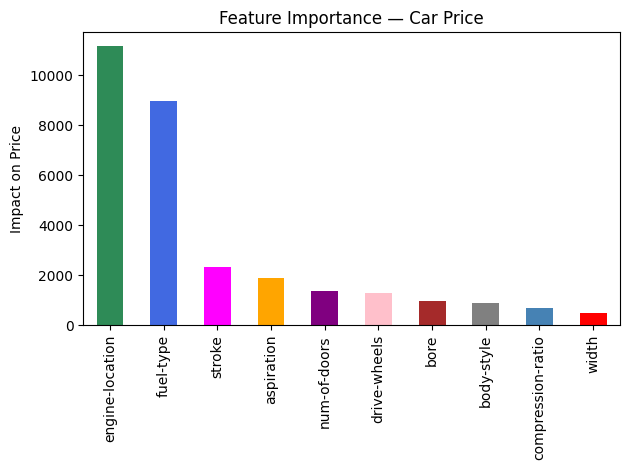

In [94]:
importance.head(10).plot(kind='bar',color=['seagreen','royalblue','magenta','orange','purple',
           'pink','brown','gray','steelblue','red'])
plt.title('Feature Importance — Car Price')
plt.ylabel('Impact on Price')
plt.tight_layout()
plt.show()